<a href="https://colab.research.google.com/github/Shreyapowar9961/Deep_Learning_sem6/blob/main/Assignment_5_%E2%80%93_CNN_on_MNIST_%26_CIFAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.utils import to_categorical

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_train = X_train.reshape(-1,28,28,1) / 255.0
X_test = X_test.reshape(-1,28,28,1) / 255.0

In [4]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [5]:
cnn_model = Sequential()

cnn_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
cnn_model.add(MaxPooling2D((2,2)))

cnn_model.add(Flatten())
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

In [7]:
history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.9432 - loss: 0.1920 - val_accuracy: 0.9753 - val_loss: 0.0865
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9800 - loss: 0.0657 - val_accuracy: 0.9811 - val_loss: 0.0666
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9863 - loss: 0.0438 - val_accuracy: 0.9842 - val_loss: 0.0592
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9897 - loss: 0.0325 - val_accuracy: 0.9811 - val_loss: 0.0697
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9928 - loss: 0.0231 - val_accuracy: 0.9837 - val_loss: 0.0593
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9947 - loss: 0.0171 - val_accuracy: 0.9827 - val_loss: 0.0604
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.9958 - loss: 0.0130 - val_accuracy: 0.9851 - val_loss: 0.0599
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9966 -

In [8]:
loss_cnn, acc_cnn = cnn_model.evaluate(X_test, y_test)
print("CNN MNIST Accuracy:", acc_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9817 - loss: 0.0686
CNN MNIST Accuracy: 0.9817000031471252


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


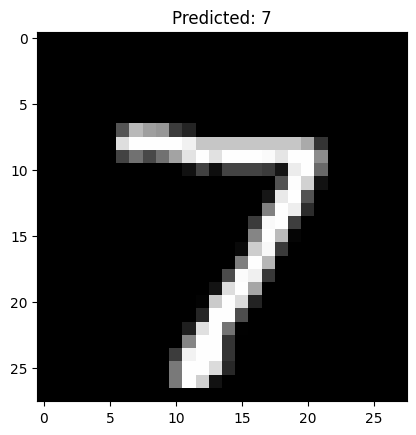

In [9]:
pred = cnn_model.predict(X_test)

plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title("Predicted: " + str(np.argmax(pred[0])))
plt.show()

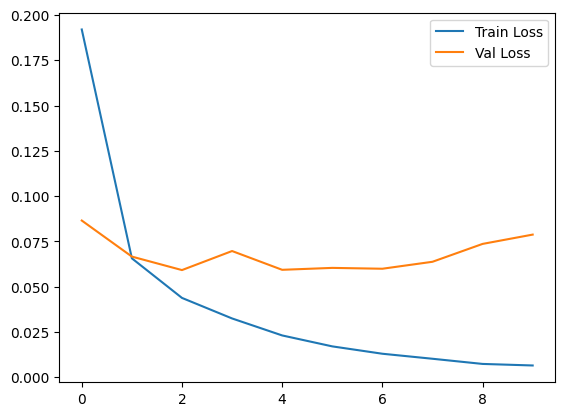

In [10]:
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

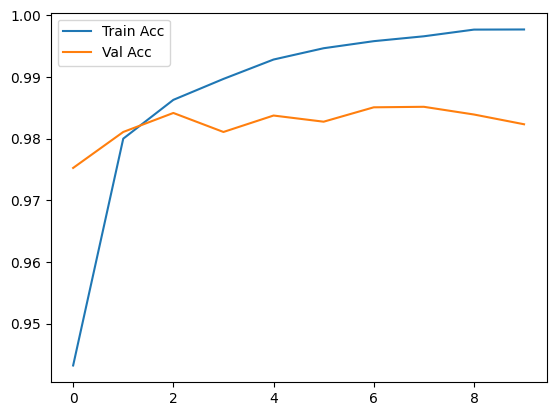

In [11]:
plt.plot(history_cnn.history['accuracy'], label='Train Acc')
plt.plot(history_cnn.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()

In [12]:
ann_model = Sequential()

ann_model.add(Flatten(input_shape=(28,28,1)))
ann_model.add(Dense(128, activation='relu'))
ann_model.add(Dense(10, activation='softmax'))

ann_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

ann_model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

loss_ann, acc_ann = ann_model.evaluate(X_test, y_test)
print("ANN MNIST Accuracy:", acc_ann)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9733 - loss: 0.0878
ANN MNIST Accuracy: 0.9732999801635742


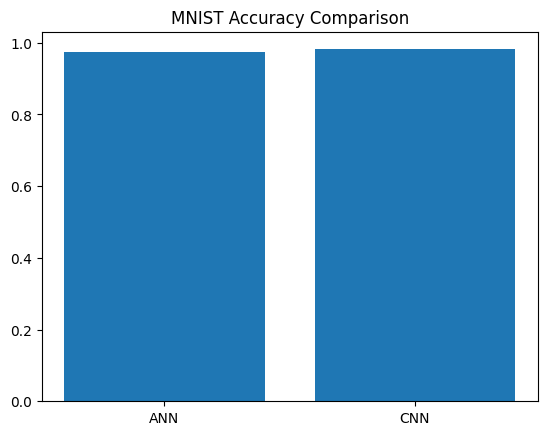

In [13]:
models = ['ANN', 'CNN']
accuracy = [acc_ann, acc_cnn]

plt.bar(models, accuracy)
plt.title("MNIST Accuracy Comparison")
plt.show()

In [14]:
from tensorflow.keras.datasets import cifar10

(X_train_c, y_train_c), (X_test_c, y_test_c) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [15]:
X_train_c = X_train_c / 255.0
X_test_c = X_test_c / 255.0

In [16]:
y_train_c = to_categorical(y_train_c, 10)
y_test_c = to_categorical(y_test_c, 10)

In [17]:
cnn_cifar = Sequential()

cnn_cifar.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
cnn_cifar.add(MaxPooling2D((2,2)))

cnn_cifar.add(Flatten())
cnn_cifar.add(Dense(64, activation='relu'))
cnn_cifar.add(Dense(10, activation='softmax'))

In [18]:
cnn_cifar.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

In [19]:
history_cifar = cnn_cifar.fit(
    X_train_c, y_train_c,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - accuracy: 0.4088 - loss: 1.6343 - val_accuracy: 0.5149 - val_loss: 1.3778
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.5466 - loss: 1.2904 - val_accuracy: 0.5621 - val_loss: 1.2523
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.5915 - loss: 1.1705 - val_accuracy: 0.5799 - val_loss: 1.2052
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.6202 - loss: 1.0918 - val_accuracy: 0.6124 - val_loss: 1.1288
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.6419 - loss: 1.0285 - val_accuracy: 0.6102 - val_loss: 1.1221
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.6574 - loss: 0.9840 - val_accuracy: 0.6242 - val_loss: 1.0820
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.6744 - loss: 0.9401 - val_accuracy: 0.6240 - val_loss: 1.1088
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.6843 -

In [20]:
loss_cifar, acc_cifar = cnn_cifar.evaluate(X_test_c, y_test_c)
print("CNN CIFAR Accuracy:", acc_cifar)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6255 - loss: 1.1071
CNN CIFAR Accuracy: 0.6255000233650208


In [21]:
ann_cifar = Sequential()

ann_cifar.add(Flatten(input_shape=(32,32,3)))
ann_cifar.add(Dense(128, activation='relu'))
ann_cifar.add(Dense(10, activation='softmax'))

ann_cifar.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

ann_cifar.fit(X_train_c, y_train_c, epochs=5, batch_size=32, verbose=0)

loss_ann_c, acc_ann_c = ann_cifar.evaluate(X_test_c, y_test_c)
print("ANN CIFAR Accuracy:", acc_ann_c)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4042 - loss: 1.6871
ANN CIFAR Accuracy: 0.4041999876499176


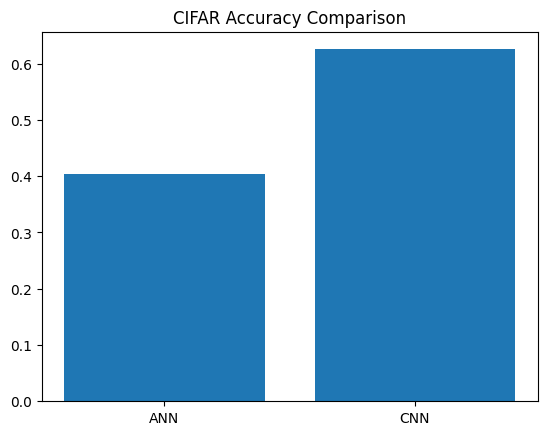

In [22]:
models = ['ANN', 'CNN']
accuracy = [acc_ann_c, acc_cifar]

plt.bar(models, accuracy)
plt.title("CIFAR Accuracy Comparison")
plt.show()